In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import nltk
import string
import pickle

path=kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")
print(path)
print(os.listdir(path))

c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Nishath Tabassum\.cache\kagglehub\datasets\suchintikasarkar\sentiment-analysis-for-mental-health\versions\1
['Combined Data.csv']


In [2]:
csv_file=[f for f in os.listdir(path) if f.endswith(".csv")][0]
df=pd.read_csv(os.path.join(path,csv_file))
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

In [4]:
df=df.dropna()
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
text_col="statement"
label_col="status"

print("Number of classes:",df[label_col].nunique())
print(df[label_col].value_counts())

Number of classes: 7
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [6]:
df["sentence_length"]=df[text_col].astype(str).apply(lambda x:len(x.split()))
print("Average sentence length:",df["sentence_length"].mean())
print(df["sentence_length"].describe())

Average sentence length: 113.15872895351265
count    52681.000000
mean       113.158729
std        163.735305
min          1.000000
25%         15.000000
50%         62.000000
75%        148.000000
max       6300.000000
Name: sentence_length, dtype: float64


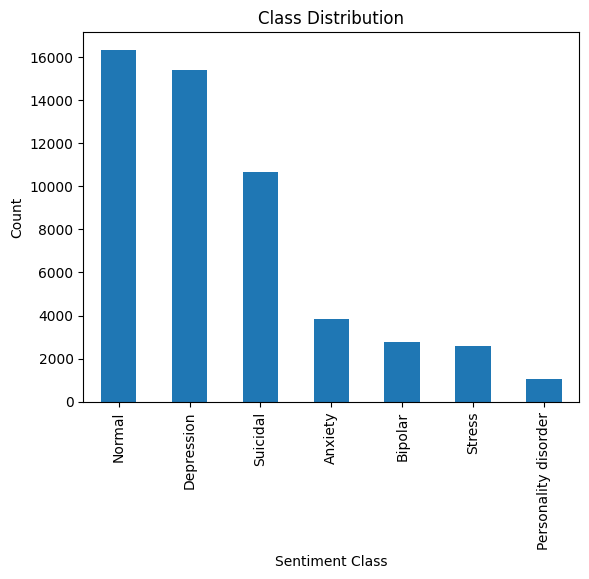

In [7]:
import matplotlib.pyplot as plt

df[label_col].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.show()

In [8]:
nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words=set(stopwords.words("english"))

def clean_text(text):
    text=str(text).lower()
    text=text.translate(str.maketrans("","",string.punctuation))
    words=text.split()
    words=[word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_text"]=df[text_col].apply(clean_text)
df[["clean_text",label_col]].head()

[nltk_data] Downloading package stopwords to C:\Users\Nishath
[nltk_data]     Tabassum\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean_text,status
0,oh gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,wrong back dear forward doubt stay restless re...,Anxiety
3,ive shifted focus something else im still worried,Anxiety
4,im restless restless month boy mean,Anxiety


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X=df["clean_text"].values
y=df[label_col].values

label_encoder=LabelEncoder()
y_encoded=label_encoder.fit_transform(y)

num_classes=len(label_encoder.classes_)
print(label_encoder.classes_)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [20]:
max_words=30000
max_len=100

tokenizer=Tokenizer(num_words=max_words,oov_token="<OOV>")
tokenizer.fit_on_texts(X)

sequences=tokenizer.texts_to_sequences(X)
padded=pad_sequences(sequences,maxlen=max_len,padding="post",truncating="post")

print("Vocabulary size:",len(tokenizer.word_index))
print("Padded shape:",padded.shape)

Vocabulary size: 81074
Padded shape: (52681, 100)


In [21]:
X_train,X_test,y_train,y_test=train_test_split(
    padded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,Dropout
from tensorflow.keras.optimizers import Adam

model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=max_len),
    SimpleRNN(128,return_sequences=False),
    Dropout(0.4),
    Dense(64,activation="relu"),
    Dropout(0.3),
    Dense(num_classes,activation="softmax")
])


c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
optimizer=Adam(learning_rate=0.0005)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stop=EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

history=model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/20


527/527 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.3405 - loss: 1.6547 - val_accuracy: 0.3901 - val_loss: 1.6128 - learning_rate: 5.0000e-04
Epoch 2/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.3652 - loss: 1.5970 - val_accuracy: 0.4636 - val_loss: 1.3903 - learning_rate: 5.0000e-04
Epoch 3/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.5184 - loss: 1.3254 - val_accuracy: 0.5487 - val_loss: 1.2116 - learning_rate: 5.0000e-04
Epoch 4/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 35s 66ms/step - accuracy: 0.5592 - loss: 1.1947 - val_accuracy: 0.5602 - val_loss: 1.1789 - learning_rate: 5.0000e-04
Epoch 5/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 33s 62ms/step - accuracy: 0.5722 - loss: 1.1205 - val_accuracy: 0.5486 - val_loss: 1.1884 - learning_rate: 5.0000e-04
Epoch 6/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.5452 - loss: 1.2138 - val_accuracy: 0.5540 - val_loss: 1.1737 - learning_rate: 5.0000e-04
Epoch 7/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accurac

In [25]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
import seaborn as sns

y_pred_probs=model.predict(X_test)
y_pred=np.argmax(y_pred_probs,axis=1)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred,average="weighted"))
print("Recall:",recall_score(y_test,y_pred,average="weighted"))
print("F1 Score:",f1_score(y_test,y_pred,average="weighted"))

print(classification_report(y_test,y_pred,target_names=label_encoder.classes_))

330/330 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Accuracy: 0.5735028945620195
Precision: 0.534596833484698
Recall: 0.5735028945620195
F1 Score: 0.48677726108011327
                      precision    recall  f1-score   support

             Anxiety       0.37      0.17      0.24       768
             Bipolar       0.44      0.29      0.35       556
          Depression       0.45      0.89      0.60      3081
              Normal       0.84      0.91      0.87      3269
Personality disorder       0.00      0.00      0.00       215
              Stress       0.17      0.04      0.06       517
            Suicidal       0.42      0.01      0.02      2131

            accuracy                           0.57     10537
           macro avg       0.38      0.33      0.30     10537
        weighted avg       0.53      0.57      0.49     10537



c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

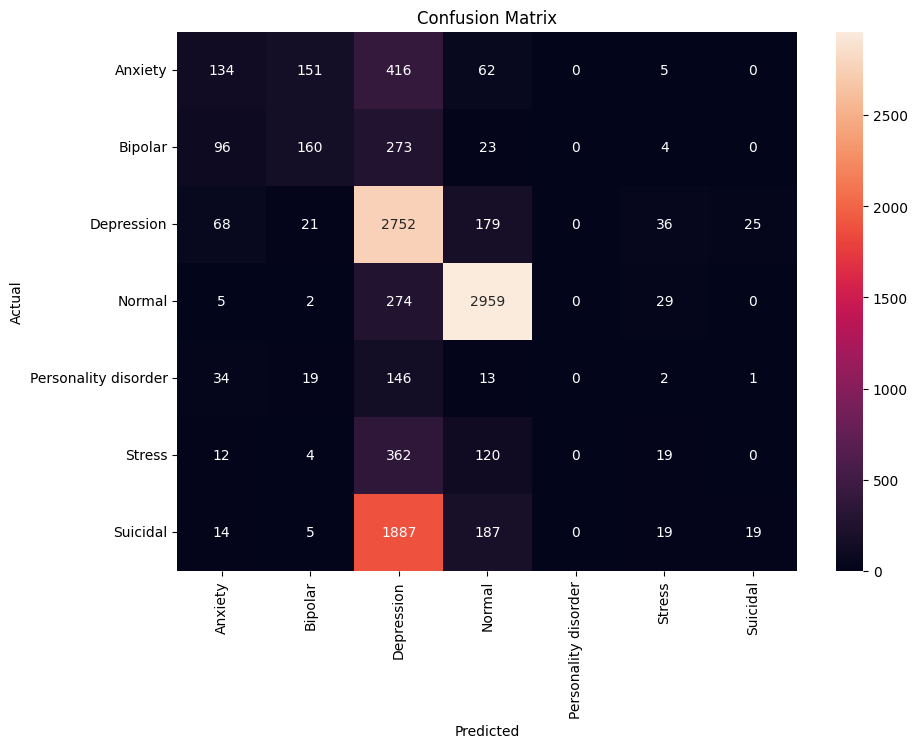

In [26]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
risk_rules={
    "Suicidal":[
        "want to die",
        "kill myself",
        "suicide",
        "end my life",
        "no reason to live",
        "hurt myself",
        "self harm",
        "i want to disappear"
    ],

    "Depression":[
        "feeling empty",
        "hopeless",
        "worthless",
        "very sad",
        "depressed",
        "nothing matters",
        "crying everyday",
        "lost interest in life"
    ],

    "Anxiety":[
        "panic attack",
        "feeling nervous",
        "overthinking",
        "cant sleep",
        "cannot sleep",
        "anxious",
        "heart racing",
        "feeling scared"
    ],

    "Stress":[
        "too much pressure",
        "stressed",
        "workload",
        "mentally exhausted",
        "burned out",
        "tired of everything",
        "overloaded"
    ],

    "Bipolar":[
        "mood swings",
        "extreme happiness",
        "extreme sadness",
        "suddenly energetic",
        "suddenly depressed"
    ],

    "Personality disorder":[
        "identity crisis",
        "unstable relationships",
        "emotional instability",
        "fear of abandonment",
        "impulsive behavior"
    ],

    "Normal":[
        "feeling happy",
        "doing well",
        "feeling calm",
        "peaceful day",
        "excited about life",
        "everything is fine"
    ]
}

In [ ]:
def predict_sentiment(sentence):

    original=sentence.lower()

    for label,phrases in risk_rules.items():

        for phrase in phrases:

            if phrase in original:

                print("Text:",sentence)
                print("Predicted Sentiment:",label)
                print("Confidence Score: Rule-Based Alert")

                if label=="Normal":
                    print("Emotional Status: Stable or positive emotional pattern.")

                else:
                    print("Emotional Status: Negative emotional trend detected.")

                return

    cleaned=clean_text(sentence)

    seq=tokenizer.texts_to_sequences([cleaned])

    pad=pad_sequences(
        seq,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    pred=model.predict(pad,verbose=0)

    class_index=np.argmax(pred)

    confidence=np.max(pred)*100

    label=label_encoder.inverse_transform([class_index])[0]

    print("Text:",sentence)
    print("Predicted Sentiment:",label)
    print("Confidence Score:",round(confidence,2),"%")

    if label.lower()=="normal":
        print("Emotional Status: Stable or positive emotional pattern.")

    else:
        print("Emotional Status: Negative emotional trend detected.")

In [38]:
predict_sentiment("I feel hopeless and tired of everything")
predict_sentiment("I am happy and excited about my future")
predict_sentiment("I feel anxious and cannot sleep properly")
predict_sentiment("Today was normal and peaceful")

Text: I feel hopeless and tired of everything
Predicted Sentiment: Depression
Confidence Score: 23.93 %
Emotional Status: Negative sentiment detected.
Text: I am happy and excited about my future
Predicted Sentiment: Normal
Confidence Score: 98.82 %
Emotional Status: Stable or positive emotional pattern.
Text: I feel anxious and cannot sleep properly
Predicted Sentiment: Depression
Confidence Score: 48.62 %
Emotional Status: Negative sentiment detected.
Text: Today was normal and peaceful
Predicted Sentiment: Normal
Confidence Score: 94.89 %
Emotional Status: Stable or positive emotional pattern.


In [39]:
predict_sentiment("I want to die")

Text: I want to die
Predicted Sentiment: Suicidal
Confidence Score: Rule-Based Alert
Emotional Status: High-risk negative sentiment detected. Immediate counselor attention needed.


In [40]:
predict_sentiment("I am getting panic attacks everyday")

Text: I am getting panic attacks everyday
Predicted Sentiment: Depression
Confidence Score: 40.02 %
Emotional Status: Negative sentiment detected.


In [41]:
model.save("mental_health_rnn_model.keras")

In [42]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

In [43]:
with open("label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder,f)

In [45]:
from tensorflow.keras.models import load_model

loaded_model=load_model("mental_health_rnn_model.keras")

In [46]:
with open("tokenizer.pkl","rb") as f:
    loaded_tokenizer=pickle.load(f)

In [47]:
with open("label_encoder.pkl","rb") as f:
    loaded_label_encoder=pickle.load(f)